# Brazil E-Commerce — Geolocation Analysis

Analysis of the **Olist `olist_geolocation_dataset.csv`** file only.

Columns:
- `geolocation_zip_code_prefix` — first 5 digits of the zip code
- `geolocation_lat` — latitude
- `geolocation_lng` — longitude
- `geolocation_city` — city name
- `geolocation_state` — 2-letter state code

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
geo = pd.read_csv("Data/olist_geolocation_dataset.csv", dtype={"geolocation_zip_code_prefix": str})
print(f"Shape: {geo.shape[0]:,} rows x {geo.shape[1]} columns")
geo.head()

Shape: 1,000,163 rows x 5 columns


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01037,-23.545621,-46.639292,sao paulo,SP
1,01046,-23.546081,-46.644820,sao paulo,SP
2,01046,-23.546129,-46.642951,sao paulo,SP
3,01041,-23.544392,-46.639499,sao paulo,SP
4,01035,-23.541578,-46.641607,sao paulo,SP


In [3]:
geo.info()
geo.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  object 
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), object(3)
memory usage: 38.2+ MB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1000163,1.000163e+06,1.000163e+06,1000163,1000163
unique,19015,NaN,NaN,8011,27
top,24220,NaN,NaN,sao paulo,SP
freq,1146,NaN,NaN,135800,404268
mean,NaN,-2.117615e+01,-4.639054e+01,NaN,NaN
std,NaN,5.715866e+00,4.269748e+00,NaN,NaN
min,NaN,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,NaN,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,NaN,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,NaN,-1.997962e+01,-4.376771e+01,NaN,NaN


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(geo.isna().sum())

dup = geo.duplicated().sum()
print(f"\nFully duplicated rows: {dup:,} ({dup / len(geo):.1%})")

Missing values per column:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Fully duplicated rows: 261,831 (26.2%)


In [5]:
# Brazil's approximate geographic bounding box.
# Lat ~ -34 (south) to +5 (north), Lng ~ -74 (west) to -34 (east).
lat_ok = geo["geolocation_lat"].between(-34.0, 5.5)
lng_ok = geo["geolocation_lng"].between(-74.0, -34.0)
out_of_bounds = ~(lat_ok & lng_ok)
print(f"Coordinates outside Brazil's bounding box: {out_of_bounds.sum():,} ({out_of_bounds.mean():.2%})")

Coordinates outside Brazil's bounding box: 42 (0.00%)


In [6]:
# Clean copy: drop exact duplicates and out-of-bounds coordinates.
geo_clean = geo[~out_of_bounds].drop_duplicates().reset_index(drop=True)
print(f"Clean rows: {len(geo_clean):,} (removed {len(geo) - len(geo_clean):,})")

Clean rows: 738,299 (removed 261,864)


## 3. Coverage by state

Distinct states: 27


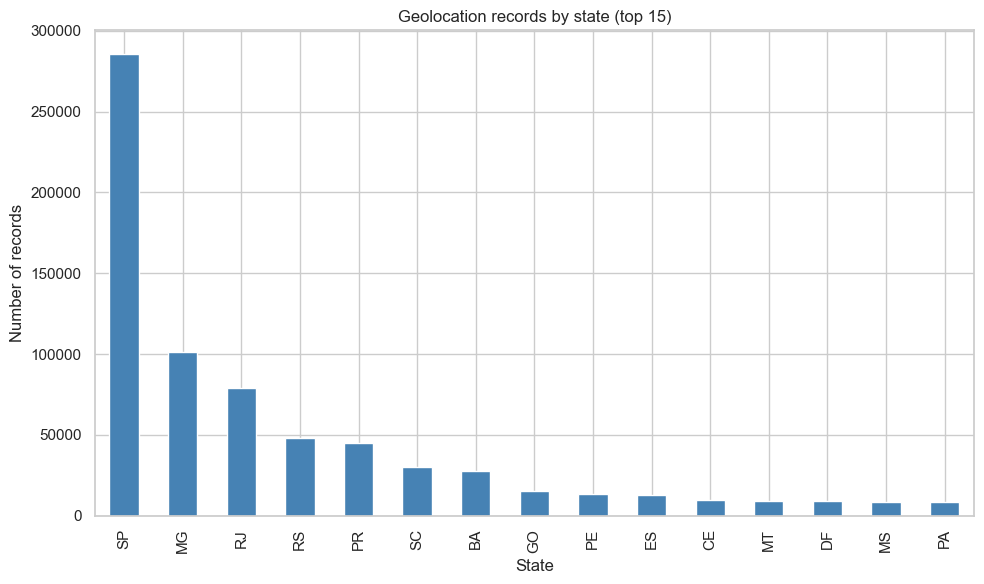

In [7]:
by_state = geo_clean["geolocation_state"].value_counts()
print(f"Distinct states: {by_state.shape[0]}")

ax = by_state.head(15).plot(kind="bar", color="steelblue")
ax.set_title("Geolocation records by state (top 15)")
ax.set_xlabel("State")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

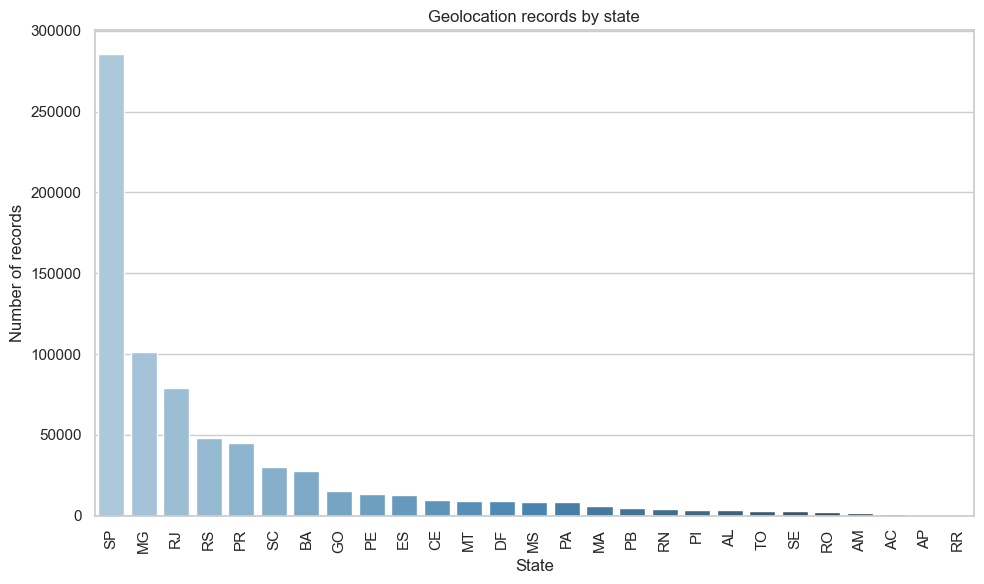

In [20]:
#OR

sns.barplot(x=by_state.index, y=by_state.values, palette="Blues_d")
plt.title("Geolocation records by state")
plt.xlabel("State")
plt.ylabel("Number of records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Coverage by city

Distinct city names: 8,006


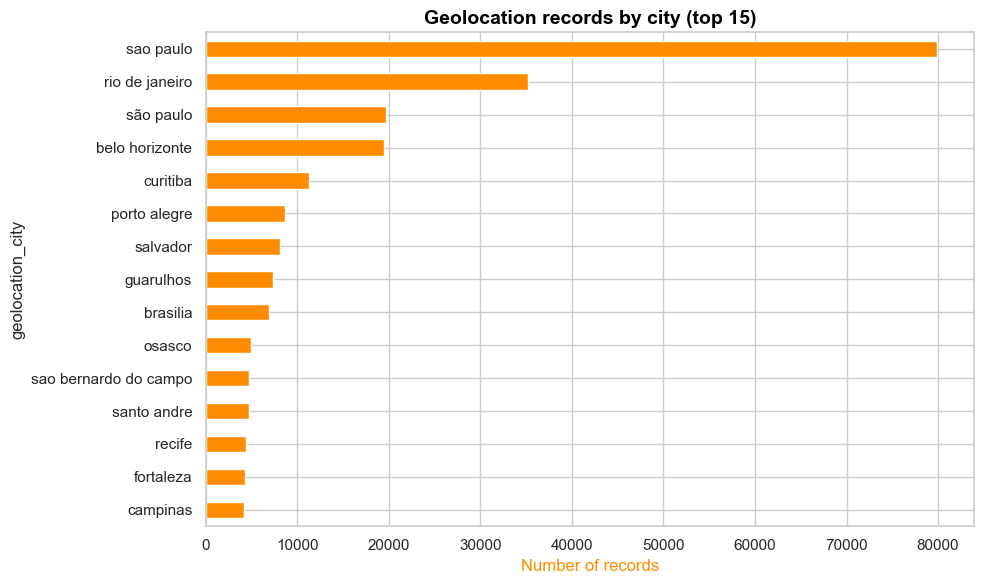

In [23]:
by_city = geo_clean["geolocation_city"].value_counts()
print(f"Distinct city names: {by_city.shape[0]:,}")

ax = by_city.head(15).plot(kind="barh", color="darkorange")
ax.invert_yaxis()
ax.set_title("Geolocation records by city (top 15)", color="black", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of records", color="darkorange")
plt.tight_layout()
plt.show()

## 5. Unique locations per zip code prefix

Each zip prefix can map to many lat/lng points. We aggregate to one representative
(median) coordinate per prefix to reduce noise for mapping.

In [9]:
zip_centroids = (
    geo_clean.groupby("geolocation_zip_code_prefix")
    .agg(
        lat=("geolocation_lat", "median"),
        lng=("geolocation_lng", "median"),
        state=("geolocation_state", lambda s: s.mode().iat[0]),
        city=("geolocation_city", lambda s: s.mode().iat[0]),
        n_points=("geolocation_lat", "size"),
    )
    .reset_index()
)
print(f"Distinct zip prefixes: {len(zip_centroids):,}")
zip_centroids.head()

Distinct zip prefixes: 19,010


,geolocation_zip_code_prefix,lat,lng,state,city,n_points
0,01001,-23.549951,-46.634027,SP,sao paulo,11
1,01002,-23.548228,-46.635247,SP,sao paulo,6
2,01003,-23.548977,-46.635313,SP,sao paulo,11
3,01004,-23.549550,-46.634771,SP,sao paulo,14
4,01005,-23.549763,-46.636100,SP,sao paulo,13


## 6. Scatter map of Brazil

Plotting the per-prefix centroids gives a recognisable map of Brazil, colour-coded by state.

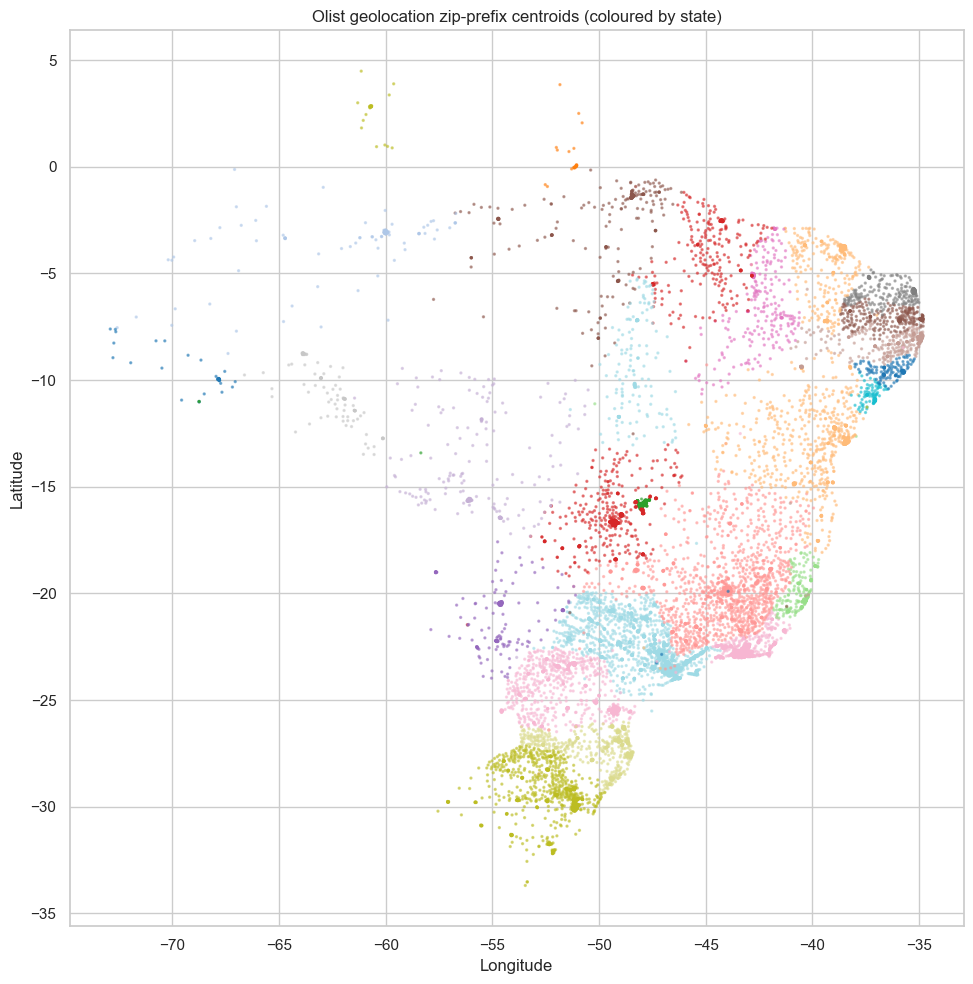

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    zip_centroids["lng"],
    zip_centroids["lat"],
    c=zip_centroids["state"].astype("category").cat.codes,
    cmap="tab20",
    s=2,
    alpha=0.5,
)
ax.set_title("Olist geolocation zip-prefix centroids (coloured by state)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Density heatmap (2D histogram)

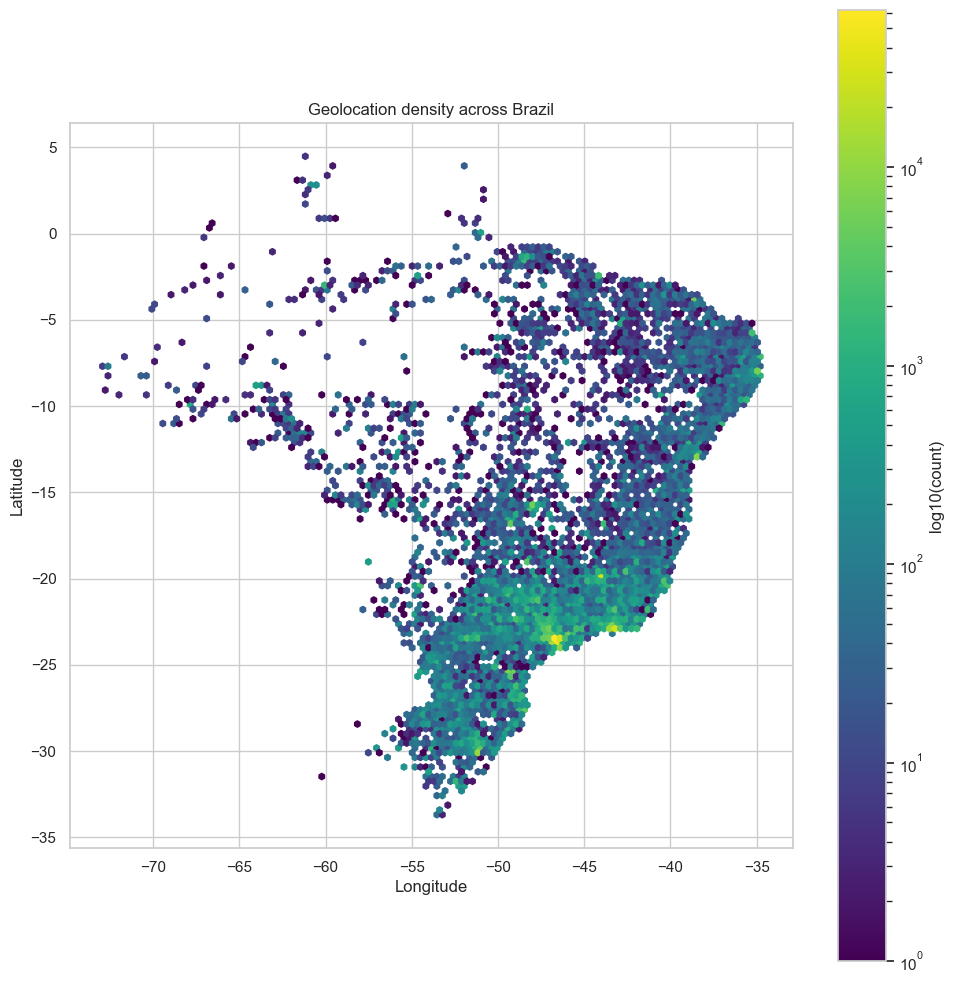

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
hb = ax.hexbin(
    geo_clean["geolocation_lng"],
    geo_clean["geolocation_lat"],
    gridsize=120,
    cmap="viridis",
    bins="log",
)
fig.colorbar(hb, ax=ax, label="log10(count)")
ax.set_title("Geolocation density across Brazil")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. State-level summary table

In [24]:
state_summary = (
    geo_clean.groupby("geolocation_state")
    .agg(
        records=("geolocation_lat", "size"),
        zip_prefixes=("geolocation_zip_code_prefix", "nunique"),
        cities=("geolocation_city", "nunique"),
        mean_lat=("geolocation_lat", "mean"),
        mean_lng=("geolocation_lng", "mean"),
    )
    .sort_values("cities", ascending=False)
)
state_summary

,records,zip_prefixes,cities,mean_lat,mean_lng
geolocation_state,,,,,
MG,101351,1868,1426,-19.858325,-44.448387
SP,285975,6348,1047,-23.086859,-47.161916
RS,48090,1131,690,-29.650351,-52.068016
BA,27716,992,652,-13.067213,-39.630053
PR,45057,1045,650,-24.764561,-50.952582
SC,30191,620,420,-27.221521,-49.635839
GO,15601,773,384,-16.567440,-49.344447
MA,6277,313,299,-3.821203,-44.818273
PI,3592,307,278,-5.700164,-42.486986


## 9. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- Coverage is heavily concentrated in the Southeast (SP, RJ, MG), with São Paulo dominating.
- The scatter map reproduces Brazil's coastline and populated interior.
- A non-trivial share of rows are exact duplicates; deduplicating per zip prefix is recommended before joining to customers/sellers.